## Neural Network

In [45]:

#import needed packages
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Packages for data preprocessing and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Used for implementing cross validation
import itertools

import random

# Function to set seeds for reproducibility
def set_seed(seed=42):
    """Set seeds for reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(42)


In [32]:
#import data in 
X_train = pd.read_csv('../data/X_train_data.csv')
y_train = pd.read_csv('../data/Y_train_data.csv')
#grab the values 
X_train = X_train.values
y_train = y_train.values
#turn the data into floats
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()


In [33]:
#further split the data
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [34]:
#check data size
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)


torch.Size([7864, 84])
torch.Size([7864, 1])
torch.Size([1967, 84])
torch.Size([1967, 1])


In [35]:
#scale the data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [36]:
#transform the data into tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

/var/folders/hj/pwp8mnp90wb03qbkc2c60_500000gn/T/ipykernel_1353/1084365509.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
/var/folders/hj/pwp8mnp90wb03qbkc2c60_500000gn/T/ipykernel_1353/1084365509.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_tensor = torch.tensor(y_val, dtype=torch.float32)


In [37]:
#train the neural network and optimize the parameters
class Net(nn.Module):
    def __init__(self, input_size=84, hidden_layers=[256, 128, 64]):
        super(Net, self).__init__()
        layers = []
        in_features = input_size
        
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            in_features = hidden_size
            
        layers.append(nn.Linear(in_features, 1))
        
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def train_and_evaluate(model, optimizer, criterion, X_train, y_train, X_val, y_val, epochs=50, batch_size=64):
    num_samples = X_train.shape[0]
    
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(num_samples)
        
        for i in range(0, num_samples, batch_size):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X_train[indices], y_train[indices]
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_mse = torch.mean((val_outputs - y_val)**2).item()
        
    return val_mse

# Hyperparameter Grid
param_grid = {
    'num_layers': [1, 2, 3],
    'num_neurons': [64, 128, 256],
    'epochs': [50, 100, 125, 150]
}

# Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_mse = float('inf')
best_params = None
results = []

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Starting Grid Search with {len(combinations)} combinations...")

for i, params in enumerate(combinations):
    print(f"\nEvaluating config {i+1}/{len(combinations)}: {params}")
    
    fold_mses = []
    
    # K-Fold Loop
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_tensor)):
        # Split data
        X_tr_fold, X_val_fold = X_train_tensor[train_idx], X_train_tensor[val_idx]
        y_tr_fold, y_val_fold = y_train_tensor[train_idx], y_train_tensor[val_idx]
        
        # Prepare hidden layers config
        hidden_layers = [params['num_neurons']] * params['num_layers']
        
        # Initialize model
        model = Net(input_size=84, hidden_layers=hidden_layers)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        # Train and Evaluate
        mse = train_and_evaluate(model, optimizer, criterion, X_tr_fold, y_tr_fold, X_val_fold, y_val_fold, epochs=params['epochs'])
        fold_mses.append(mse)
    
    avg_mse = np.mean(fold_mses)
    print(f"Avg MSE: {avg_mse:.4f}")
    
    results.append({'params': params, 'mse': avg_mse})
    # Update best model
    if avg_mse < best_mse:
        best_mse = avg_mse
        best_params = params

print(f"\nBest Config: {best_params}")
print(f"Best MSE: {best_mse:.4f}")


Starting Grid Search with 36 combinations...

Evaluating config 1/36: {'num_layers': 1, 'num_neurons': 64, 'epochs': 50}
Avg MSE: 0.2681

Evaluating config 2/36: {'num_layers': 1, 'num_neurons': 64, 'epochs': 100}
Avg MSE: 0.2745

Evaluating config 3/36: {'num_layers': 1, 'num_neurons': 64, 'epochs': 125}
Avg MSE: 0.2712

Evaluating config 4/36: {'num_layers': 1, 'num_neurons': 64, 'epochs': 150}
Avg MSE: 0.2887

Evaluating config 5/36: {'num_layers': 1, 'num_neurons': 128, 'epochs': 50}
Avg MSE: 0.2591

Evaluating config 6/36: {'num_layers': 1, 'num_neurons': 128, 'epochs': 100}
Avg MSE: 0.2677

Evaluating config 7/36: {'num_layers': 1, 'num_neurons': 128, 'epochs': 125}
Avg MSE: 0.2772

Evaluating config 8/36: {'num_layers': 1, 'num_neurons': 128, 'epochs': 150}
Avg MSE: 0.2773

Evaluating config 9/36: {'num_layers': 1, 'num_neurons': 256, 'epochs': 50}
Avg MSE: 0.2605

Evaluating config 10/36: {'num_layers': 1, 'num_neurons': 256, 'epochs': 100}
Avg MSE: 0.2561

Evaluating config 11

In [42]:

class OptimalNet(nn.Module):
    def __init__(self):
        super(OptimalNet, self).__init__()
        # Input layer: 84 features
        self.fc1 = nn.Linear(84, 256)
        # Output layer: 1 unit for regression
        self.fc2 = nn.Linear(256, 1)
        

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def train_model():

    net = OptimalNet()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)

    # 5. Training Loop
    epochs = 100
    batch_size = 64
    num_samples = X_train_tensor.shape[0]
    
    train_losses = []
    val_losses = []
    
    print("Starting training...")
    for epoch in range(epochs):
        net.train()
        # shuffle the data
        permutation = torch.randperm(num_samples)
        
        train_loss = 0.0
        for i in range(0, num_samples, batch_size):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]
            
            optimizer.zero_grad()
            outputs = net(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_x.size(0)
            
        train_loss /= num_samples
        train_losses.append(train_loss)
        
        # Validation step
        net.eval()
        with torch.no_grad():
            # predict on the validation set
            val_outputs = net(X_val_tensor)
            # calculate performance metrics
            val_loss = criterion(val_outputs, y_val_tensor).item()
            val_mse = torch.mean((val_outputs - y_val_tensor)**2).item()
            val_acc = (torch.abs(val_outputs - y_val_tensor) <= 1.0).float().mean().item() * 100
            
            val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MSE: {val_mse:.4f} | Val Acc: {val_acc:.2f}%")

    return net, train_losses, val_losses


Starting training...
Epoch [10/100] | Train Loss: 0.1856 | Val Loss: 0.2692 | Val MSE: 0.2692 | Val Acc: 95.63%
Epoch [20/100] | Train Loss: 0.1359 | Val Loss: 0.2523 | Val MSE: 0.2523 | Val Acc: 95.42%
Epoch [30/100] | Train Loss: 0.1128 | Val Loss: 0.2513 | Val MSE: 0.2513 | Val Acc: 95.93%
Epoch [40/100] | Train Loss: 0.1005 | Val Loss: 0.2487 | Val MSE: 0.2487 | Val Acc: 96.14%
Epoch [50/100] | Train Loss: 0.0878 | Val Loss: 0.2382 | Val MSE: 0.2382 | Val Acc: 95.83%
Epoch [60/100] | Train Loss: 0.0794 | Val Loss: 0.2596 | Val MSE: 0.2596 | Val Acc: 95.83%
Epoch [70/100] | Train Loss: 0.0705 | Val Loss: 0.2382 | Val MSE: 0.2382 | Val Acc: 95.48%
Epoch [80/100] | Train Loss: 0.0699 | Val Loss: 0.2434 | Val MSE: 0.2434 | Val Acc: 95.68%
Epoch [90/100] | Train Loss: 0.0727 | Val Loss: 0.2359 | Val MSE: 0.2359 | Val Acc: 95.58%
Epoch [100/100] | Train Loss: 0.0653 | Val Loss: 0.2448 | Val MSE: 0.2448 | Val Acc: 96.14%


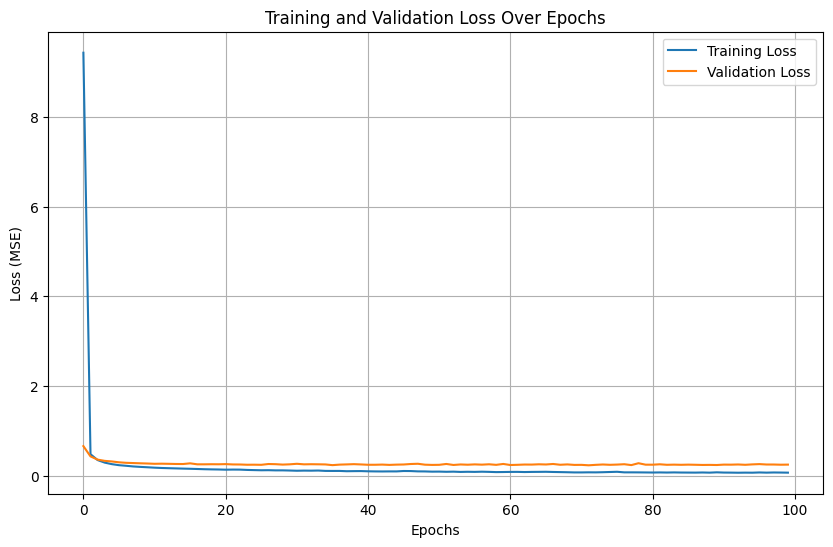

In [46]:
# train the model
net, train_losses, val_losses = train_model()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()
